# Autoencoder - on the MNIST dataset:

The following is an illustration/exercise in using an Auto-Encoder on image data. The general idea is, that if one can encode (i.e. represent with "few" parameters) images, and then from this encoding decode them again to obtain "almost" the same images, then the few parameters (in a latent space) contains the basic information about the images.

![](https://github.com/DracoArgenteus/AppliedML2025/blob/rapid-minnow-moccasin/Week4/AutoEncoder.png?raw=1 "")

An AutoEncoder is trained by requiring that the output images match the input images *best possible*, which is (of course) represented by a loss function. Thus, **an AutoEncoder does not require labels**, and is as such unsupervised learning. The power lies in that one gets a good representation of the data through the latent space (the size of which you can choose) for essentially any NN-based method, here a CNN.

This can then be used (aggresively!) for many things such as:
* Compression (with loss!) of the images (to the size of the latent space)
* De-noising images
* Anomaly detection
* Unsupervised learning (e.g. clustering) on images, sound, graphs, etc.

In the example at hand, we consider the MNIST dataset (28x28 (=784) images of digits), and autoencode these images into a latent space of size 4. We then project this latent space onto just two dimensions using UMAP, and see if we (or a clustering algorithm) can detect clusters and possibly determine how many digits there are... *without ever having known anything about arabic numerals!!!*

***

Authors: Amalie Mygind and Troels Petersen (based on example from Medium)<br>

Date: 4th of May 2025 (latest version)

In [35]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

from umap import UMAP

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

import itertools
from tqdm import tqdm

In [34]:
# mine

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device:', device)

device: cuda


***

In [2]:
# Convert data to torch.FloatTensor
transform = transforms.ToTensor()
# transforms.Normalize() ?

# Load the training and test datasets
train_dataset = datasets.MNIST('dataset', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST('dataset', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.80MB/s]


In [3]:
# Split training data into training and validation data:
full_len = len(train_dataset)
train_data, val_data = random_split(train_dataset, [int(full_len-full_len*0.2), int(full_len*0.2)])
batch_size=256

### Question - do we need to split the data?

We somehow always split the data into these three datasets, but given that we are doing unsupervised learning here, try to think about the degree to which we need to divide the data in this way.

In [4]:
# Create PyTorch dataloaders for data:
train_loader = DataLoader(train_data, batch_size=batch_size)
valid_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Define the autoencoder model (explained in comments below):

class Encoder(nn.Module):

    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()

        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )

        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(3 * 3 * 32, 128),
            # nn.ReLU(True),
            nn.LeakyReLU(0.2), #mine
            nn.Dropout(0.1), #mine
            nn.Linear(128, encoded_space_dim)
        )

    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x

class Decoder(nn.Module):

    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1,
        unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [ ]:
# mine

# Hyperparameters
encoded_space_dim = 4
lr = 1e-3
weight_decay = 1e-5

# Instantiate models
encoder = Encoder(encoded_space_dim=encoded_space_dim, fc2_input_dim=128).to(device)
decoder = Decoder(encoded_space_dim=encoded_space_dim, fc2_input_dim=128).to(device)

# Optimizer (Adam is good for AE)
params_to_optimize = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=weight_decay)

# Loss function
loss_fn = nn.MSELoss()


In [6]:
# # Define loss function and training parameters:

# # Define the loss function
# loss_fn = nn.MSELoss()

# # Define an optimizer (both for the encoder and the decoder!)
# lr = 0.001

# # Set the random seed for reproducible results
# torch.manual_seed(42)

# # Initialize the two networks
# d = 4
# encoder = Encoder(encoded_space_dim=d, fc2_input_dim=128)
# decoder = Decoder(encoded_space_dim=d, fc2_input_dim=128)
# params_to_optimize = [
#     {'params': encoder.parameters()},
#     {'params': decoder.parameters()}
# ]

# optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

In [ ]:
# mine

def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer, device):
    encoder.train()
    decoder.train()
    train_loss = 0.0

    for image_batch, _ in tqdm(dataloader, desc="Training", leave=False):
        image_batch = image_batch.to(device)

        optimizer.zero_grad()

        encoded_data = encoder(image_batch)
        decoded_data = decoder(encoded_data)

        loss = loss_fn(decoded_data, image_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image_batch.size(0)  # Sum over batch

    return train_loss / len(dataloader.dataset)


def test_epoch(encoder, decoder, dataloader, loss_fn, device):
    encoder.eval()
    decoder.eval()
    val_loss = 0.0

    with torch.no_grad():
        for image_batch, _ in tqdm(dataloader, desc="Validation", leave=False):
            image_batch = image_batch.to(device)

            encoded_data = encoder(image_batch)
            decoded_data = decoder(encoded_data)

            loss = loss_fn(decoded_data, image_batch)
            val_loss += loss.item() * image_batch.size(0)

    return val_loss / len(dataloader.dataset)


# def plot_ae_outputs(encoder, decoder, test_dataset, device, n=10):
#     plt.figure(figsize=(16, 4.5))
#     targets = test_dataset.targets.numpy()
#     t_idx = {i: np.where(targets == i)[0][0] for i in range(n)}

#     encoder.eval()
#     decoder.eval()

#     for i in range(n):
#         ax = plt.subplot(2, n, i + 1)
#         img = test_dataset[t_idx[i]][0].unsqueeze(0).to(device)

#         with torch.no_grad():
#             rec_img = decoder(encoder(img))

#         plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
#         ax.get_xaxis().set_visible(False)
#         ax.get_yaxis().set_visible(False)
#         if i == n // 2:
#             ax.set_title('Original images')

#         ax = plt.subplot(2, n, i + 1 + n)
#         plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
#         ax.get_xaxis().set_visible(False)
#         ax.get_yaxis().set_visible(False)
#         if i == n // 2:
#             ax.set_title('Reconstructed images')

#     plt.tight_layout()
#     plt.show()

def plot_ae_outputs(encoder, decoder, dataset, device, n=10):
    encoder.eval()
    decoder.eval()

    plt.figure(figsize=(16, 4.5))
    targets = dataset.targets.numpy()
    t_idx = {i: np.where(targets == i)[0][0] for i in range(n)}

    for i in range(n):
        img = dataset[t_idx[i]][0].unsqueeze(0).to(device)

        with torch.no_grad():
            rec_img = decoder(encoder(img))

        # Original image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.axis('off')
        if i == n // 2:
            ax.set_title('Original Images')

        # Reconstructed image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.axis('off')
        if i == n // 2:
            ax.set_title('Reconstructed Images')

    plt.show()



In [7]:
# # Define training and validation functions:

# ### Training function
# def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer):
#     # Set train mode for both the encoder and the decoder
#     encoder.train()
#     decoder.train()
#     train_loss = []
#     # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
#     for image_batch, _ in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
#         # Encode data
#         encoded_data = encoder(image_batch)
#         # Decode data
#         decoded_data = decoder(encoded_data)
#         # Evaluate loss
#         loss = loss_fn(decoded_data, image_batch)
#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         # Print batch loss
# #         print('\t partial train loss (single batch): %f' % (loss.data))
#         train_loss.append(loss.detach().cpu().numpy())

#     return np.mean(train_loss)


# ### Testing function
# def test_epoch(encoder, decoder, dataloader, loss_fn):
#     # Set evaluation mode for encoder and decoder
#     encoder.eval()
#     decoder.eval()
#     with torch.no_grad(): # No need to track the gradients
#         # Define the lists to store the outputs for each batch
#         conc_out = []
#         conc_label = []
#         for image_batch, _ in dataloader:
#             # Encode data
#             encoded_data = encoder(image_batch)
#             # Decode data
#             decoded_data = decoder(encoded_data)
#             # Append the network output and the original image to the lists
#             conc_out.append(decoded_data.cpu())
#             conc_label.append(image_batch.cpu())
#         # Create a single tensor with all the values in the lists
#         conc_out = torch.cat(conc_out)
#         conc_label = torch.cat(conc_label)
#         # Evaluate global loss
#         val_loss = loss_fn(conc_out, conc_label)
#     return val_loss.data


# def plot_ae_outputs(encoder,decoder,n=10):
#     plt.figure(figsize=(16,4.5))
#     targets = test_dataset.targets.numpy()
#     t_idx = {i:np.where(targets==i)[0][0] for i in range(n)}
#     for i in range(n):

#         ax = plt.subplot(2,n,i+1)
#         img = test_dataset[t_idx[i]][0].unsqueeze(0)
#         encoder.eval()
#         decoder.eval()
#         with torch.no_grad():
#             rec_img  = decoder(encoder(img))
#         plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
#         ax.get_xaxis().set_visible(False)
#         ax.get_yaxis().set_visible(False)
#         if i == n//2:
#             ax.set_title('Original images')
#         ax = plt.subplot(2, n, i + 1 + n)
#         plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
#         ax.get_xaxis().set_visible(False)
#         ax.get_yaxis().set_visible(False)
#         if i == n//2:
#             ax.set_title('Reconstructed images')
#     plt.show()

### Question - what is the dimension of the latent space?

Ask yourself, how many dimensions we boild the images down to, i.e. how many numbers represent what the images look like?

NOTE: You may want to launch the training cell below (which takes a few minutes) and then think about the answer.

In [ ]:
# mine

# Training setup
num_epochs = 10
diz_loss = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

# Directory to save best model weights
os.makedirs("saved_models", exist_ok=True)

for epoch in range(1, num_epochs + 1):
    encoder.train()
    decoder.train()
    running_loss = 0.0

    # Training loop
    for image_batch, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False):
        image_batch = image_batch.to(device)

        optimizer.zero_grad()
        encoded = encoder(image_batch)
        decoded = decoder(encoded)
        loss = loss_fn(decoded, image_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    diz_loss['train_loss'].append(avg_train_loss)

    # Validation loop
    encoder.eval()
    decoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for image_batch, _ in test_loader:
            image_batch = image_batch.to(device)
            decoded = decoder(encoder(image_batch))
            val_loss += loss_fn(decoded, image_batch).item()

    avg_val_loss = val_loss / len(test_loader)
    diz_loss['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch:2d}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # 🔥 Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(encoder.state_dict(), "saved_models/encoder_best.pth")
        torch.save(decoder.state_dict(), "saved_models/decoder_best.pth")
        print("🔥 Best model saved!")

    # 🖼️ Plot reconstructions
    plot_ae_outputs(encoder, decoder, test_dataset, device, n=10)


In [ ]:
# # mine

# num_epochs = 10
# diz_loss = {'train_loss': [], 'val_loss': []}

# for epoch in range(1, num_epochs + 1):
#     # Training
#     encoder.train()
#     decoder.train()
#     running_loss = 0.0
#     for image_batch, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False):
#         image_batch = image_batch.to(device)

#         # Forward pass
#         encoded = encoder(image_batch)
#         decoded = decoder(encoded)
#         loss = loss_fn(decoded, image_batch)

#         # Backpropagation
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     avg_train_loss = running_loss / len(train_loader)
#     diz_loss['train_loss'].append(avg_train_loss)

#     # Validation
#     encoder.eval()
#     decoder.eval()
#     with torch.no_grad():
#         val_loss = 0.0
#         for image_batch, _ in test_loader:
#             image_batch = image_batch.to(device)
#             decoded = decoder(encoder(image_batch))
#             val_loss += loss_fn(decoded, image_batch).item()
#         avg_val_loss = val_loss / len(test_loader)
#         diz_loss['val_loss'].append(avg_val_loss)

#     print(f"Epoch {epoch:2d}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

#     # Plot sample reconstructions
#     plot_ae_outputs(encoder, decoder, test_dataset, device, n=10)




 EPOCH 1/10 	 train loss 0.1846393197774887 	 val loss 0.10267561674118042


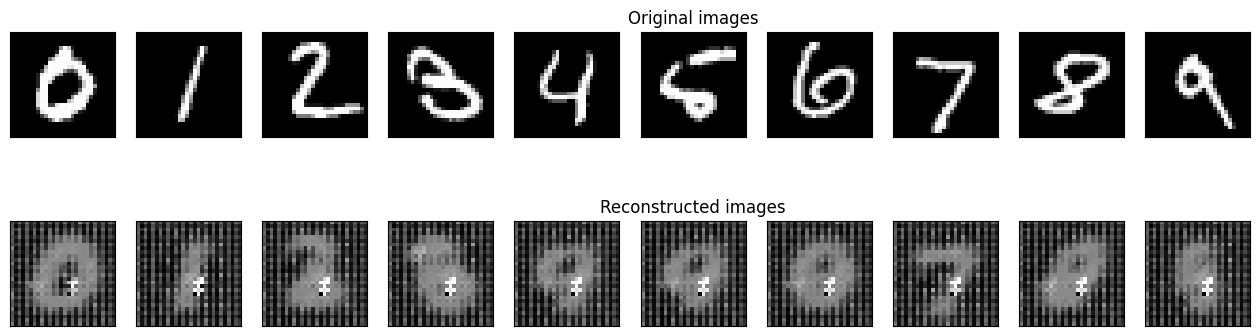


 EPOCH 2/10 	 train loss 0.07175920158624649 	 val loss 0.050123900175094604


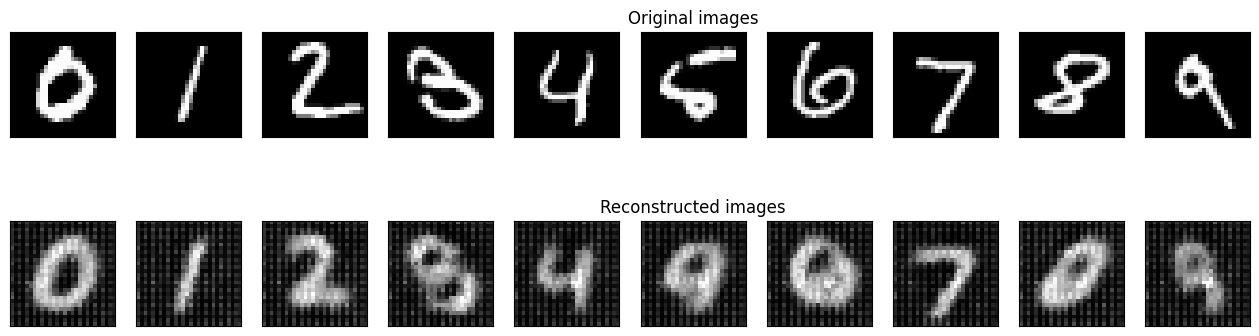


 EPOCH 3/10 	 train loss 0.04293851554393768 	 val loss 0.03810115531086922


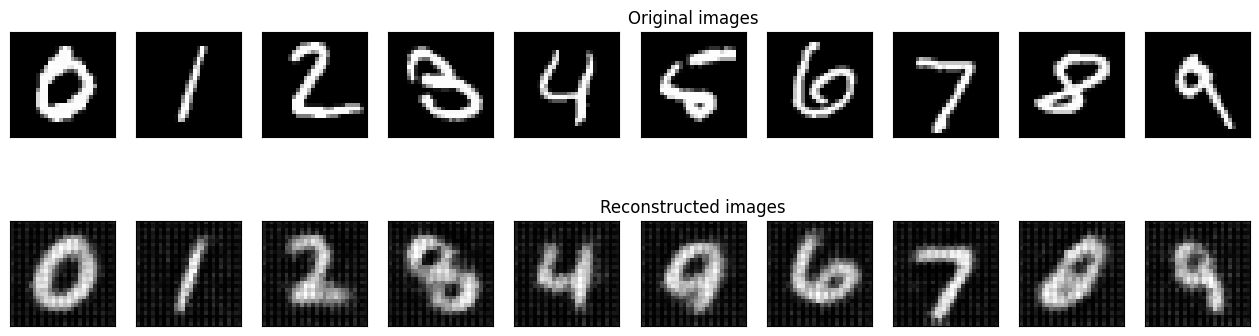


 EPOCH 4/10 	 train loss 0.035843249410390854 	 val loss 0.03417576476931572


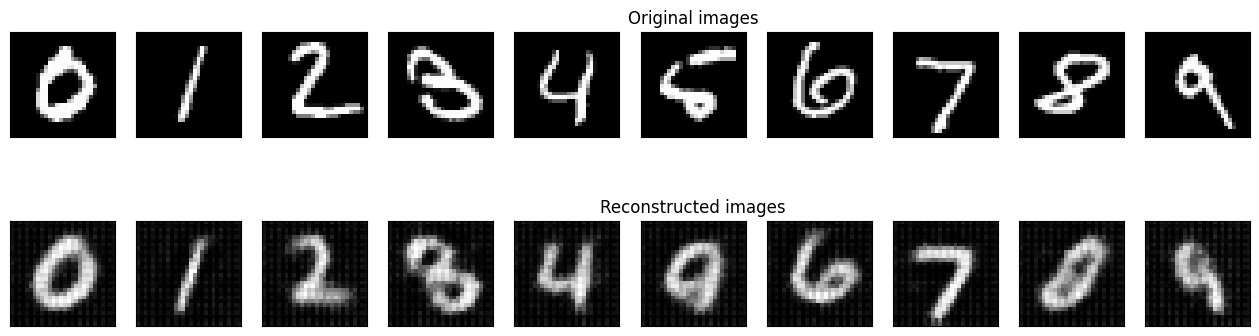


 EPOCH 5/10 	 train loss 0.032978422939777374 	 val loss 0.03220760449767113


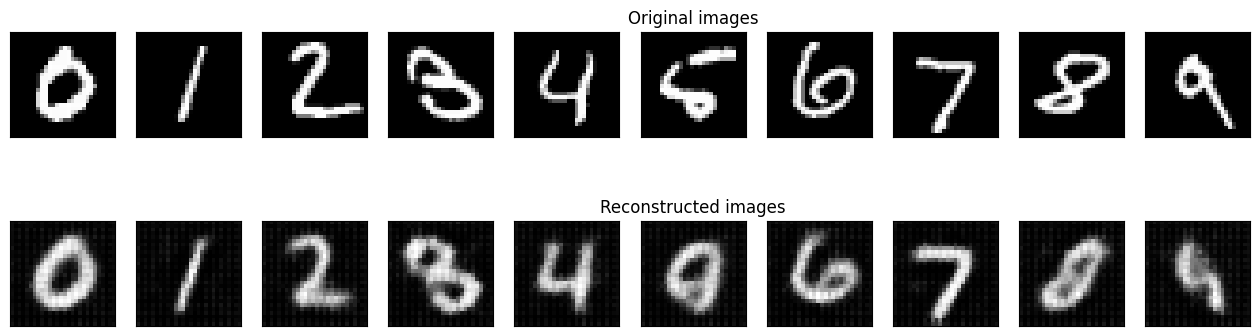


 EPOCH 6/10 	 train loss 0.031411390751600266 	 val loss 0.03108133189380169


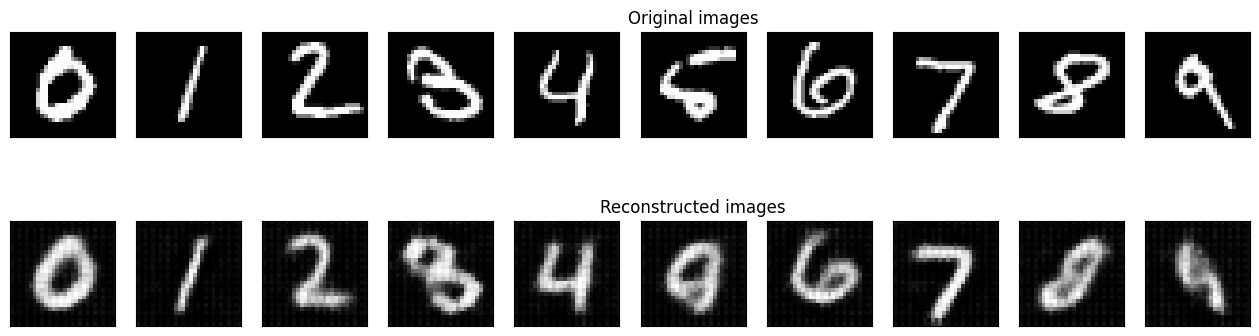


 EPOCH 7/10 	 train loss 0.03038029558956623 	 val loss 0.030173571780323982


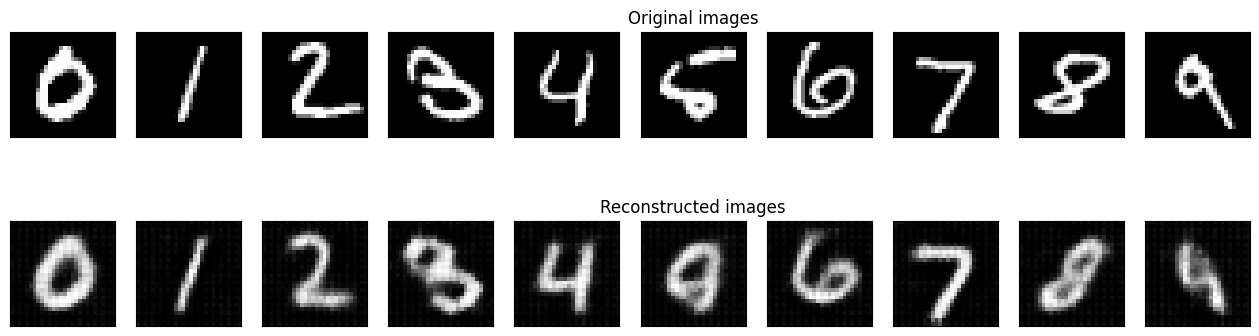


 EPOCH 8/10 	 train loss 0.029640913009643555 	 val loss 0.02962660603225231


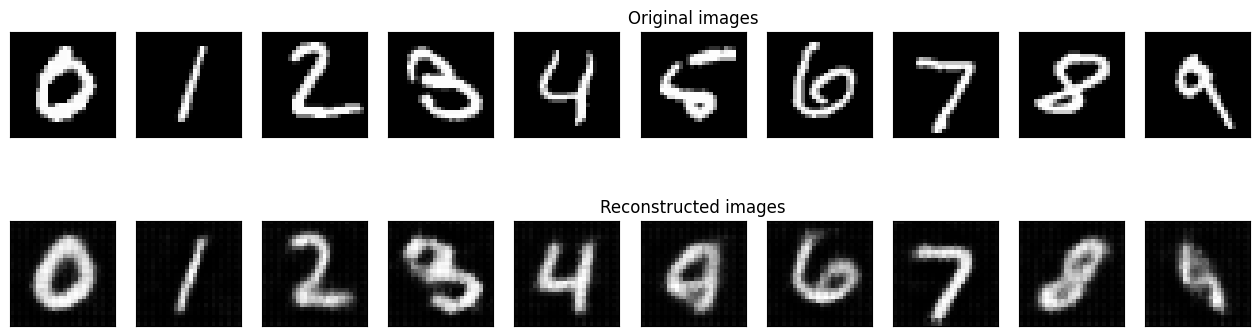


 EPOCH 9/10 	 train loss 0.029062747955322266 	 val loss 0.02903146855533123


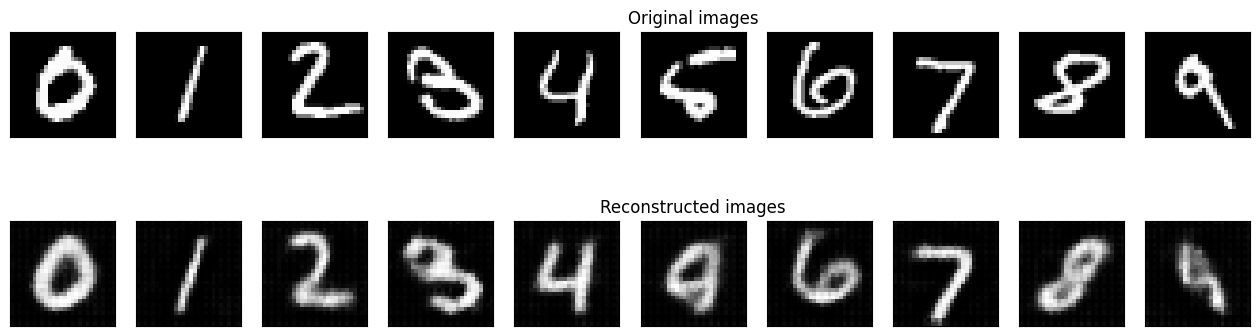


 EPOCH 10/10 	 train loss 0.02858591638505459 	 val loss 0.028564367443323135


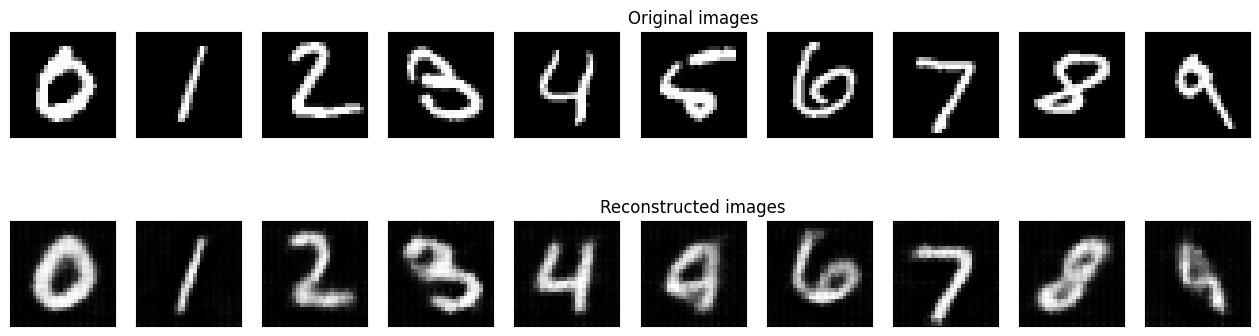

In [8]:
# # Train the model
# num_epochs = 10
# diz_loss = {'train_loss':[],'val_loss':[]}
# for epoch in range(num_epochs):
#     train_loss = train_epoch(encoder,decoder, train_loader, loss_fn, optim)
#     val_loss = test_epoch(encoder,decoder,test_loader,loss_fn)
#     print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
#     diz_loss['train_loss'].append(train_loss)
#     diz_loss['val_loss'].append(val_loss)
#     plot_ae_outputs(encoder,decoder,n=10)

***

### Save model

In [30]:
# mine

# Create a directory to store saved models (optional)
import os
os.makedirs("saved_models", exist_ok=True)

# Save model state dict (recommended)
torch.save(encoder.state_dict(), "saved_models/encoder_final.pth")
torch.save(decoder.state_dict(), "saved_models/decoder_final.pth")

# Optional: save optimizer state
torch.save(optimizer.state_dict(), "saved_models/optimizer_final.pth")

# Optional: save full models (less flexible)
torch.save(encoder, "saved_models/encoder_model_full.pth")
torch.save(decoder, "saved_models/decoder_model_full.pth")


AttributeError: module 'torch.nn' has no attribute 'save'

In [ ]:
## loading a saved model

# encoder.load_state_dict(torch.load('saved_models/encoder_best.pth'))
# decoder.load_state_dict(torch.load('saved_models/decoder_best.pth'))
# encoder.eval()
# decoder.eval()

***

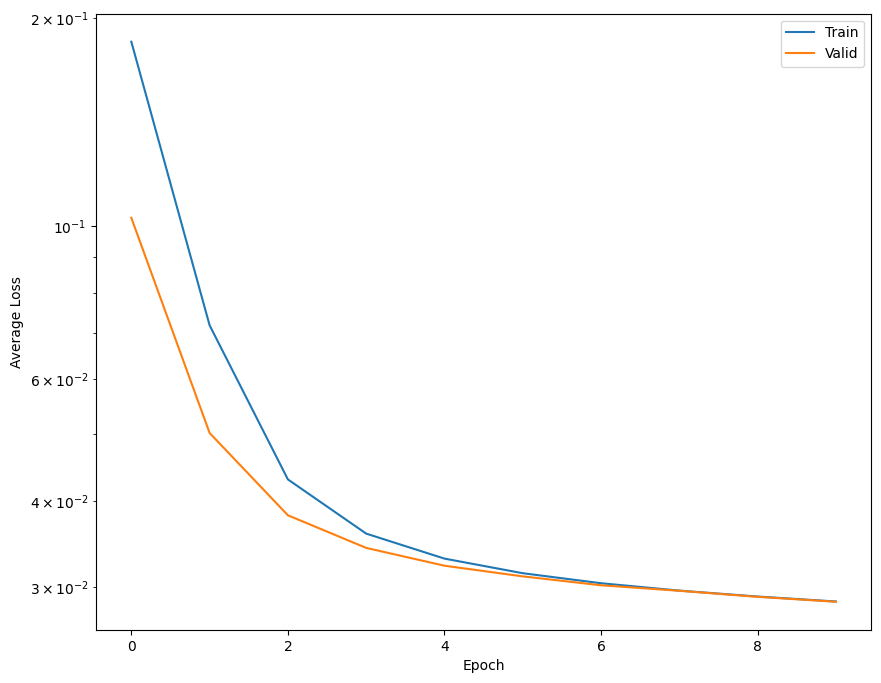

In [9]:
# Plot losses over epochs:
plt.figure(figsize=(10,8))
plt.semilogy(diz_loss['train_loss'], label='Train')
plt.semilogy(diz_loss['val_loss'], label='Valid')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
#plt.grid()
plt.legend()
#plt.title('loss')
plt.show()

### Extract latent space representation

In [10]:
# Perform forward pass on test set and subtract latent layer (and labels):
latent_test = []
labels_test = []
for step, (images, labels) in enumerate(test_loader):
    with torch.no_grad():
        latent = encoder(images)
    latent_test.extend(latent.numpy())
    labels_test.extend(labels.numpy())

# labels_str = list(map(str, labels_test))

print(f'latent shape: {np.shape(latent_test)}, labels shape: {np.shape(labels_test)}')

latent shape: (10000, 4), labels shape: (10000,)


## Reduce latent space with UMAP

In [11]:
# Fit a (possibly parametric!) UMAP embedding to the latent space representation:
# embedder = ParametricUMAP(n_epochs=50, n_neighbors=20, min_dist=0.1)
embedder = UMAP(n_neighbors=50, min_dist=0.2)
embedding = embedder.fit_transform(latent_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Question - can you "train" UMAP on a training set, and then apply the same model to a test set?

Seeing how t-SNE and UMAP iteratively got to their resulting projections, do you think that at the end of the process there is a model, that can be applied to other data? And if not, can you think about, how one could construct a good approximation?

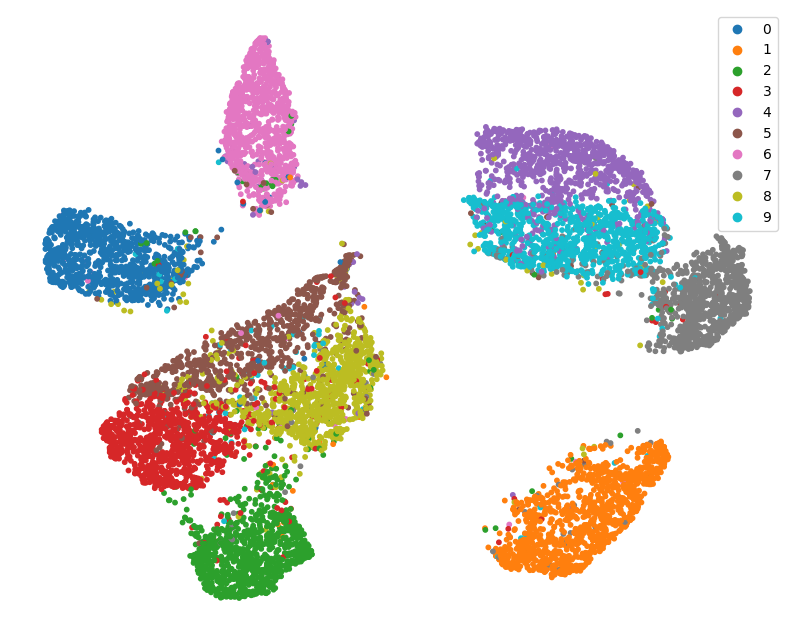

In [12]:
# Plot embedding without example images:
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.tab10
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels_test, s=10, cmap=cmap)
ax.legend(*scatter.legend_elements())
ax.axis("off");

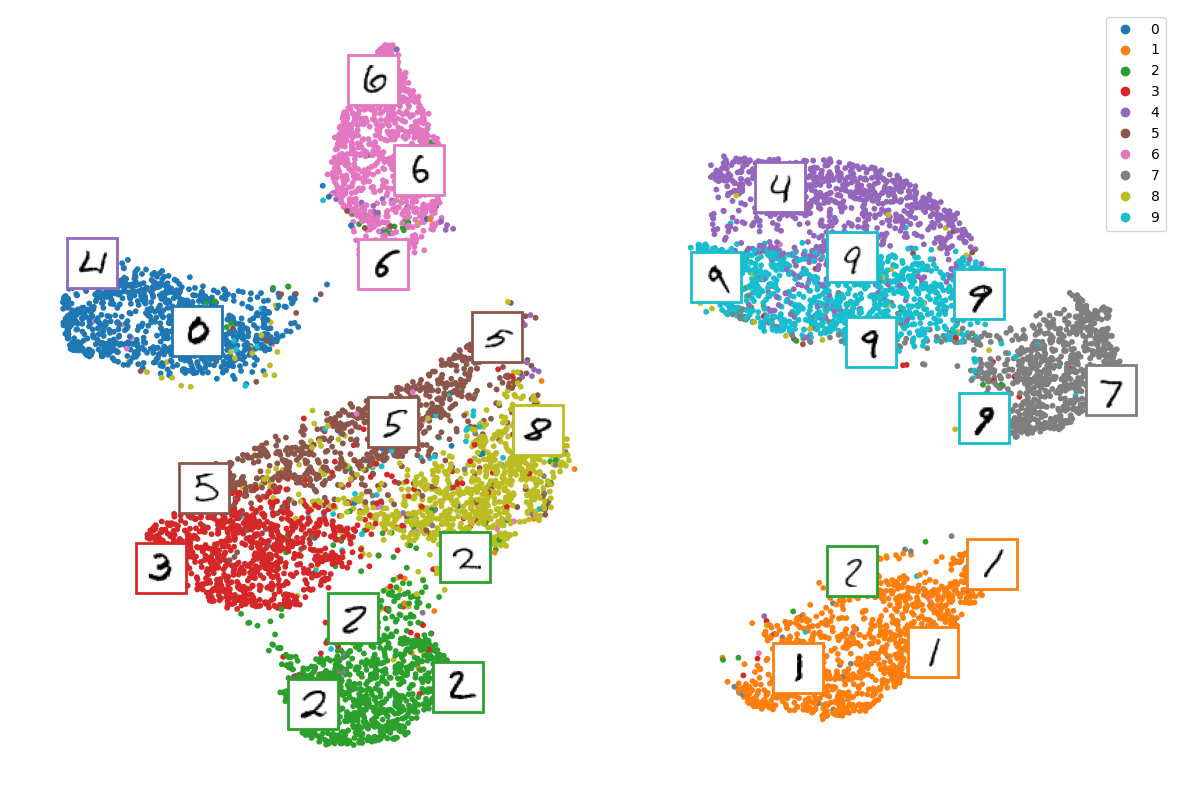

In [13]:
# Plot embedding with example images:
fig, ax = plt.subplots(figsize=(15, 10))
cmap = plt.cm.tab10
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels_test, s=10, cmap=cmap)
ax.legend(*scatter.legend_elements())
image_positions = np.array([[1., 1.]])
for index, position in enumerate(embedding):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 4:            # If far enough from other images...
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(test_dataset[index][0][0], cmap="binary"),
            position, bboxprops={"edgecolor": cmap(labels_test[index]), "lw": 2})
        fig.gca().add_artist(imagebox)
ax.axis("off");

In [14]:
# k-means clustering of embedding:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(embedding)
clusters = pd.DataFrame(kmeans.labels_, columns=['Cluster'])

classes = np.array(labels_test)
class_names = [0,1,2,3,4,5,6,7,8,9]

clust0 = clusters.loc[clusters['Cluster'] == 0].index.to_numpy()
clust1 = clusters.loc[clusters['Cluster'] == 1].index.to_numpy()
clust2 = clusters.loc[clusters['Cluster'] == 2].index.to_numpy()
clust3 = clusters.loc[clusters['Cluster'] == 3].index.to_numpy()
clust4 = clusters.loc[clusters['Cluster'] == 4].index.to_numpy()
clust5 = clusters.loc[clusters['Cluster'] == 5].index.to_numpy()
clust6 = clusters.loc[clusters['Cluster'] == 6].index.to_numpy()
clust7 = clusters.loc[clusters['Cluster'] == 7].index.to_numpy()
clust8 = clusters.loc[clusters['Cluster'] == 8].index.to_numpy()
clust9 = clusters.loc[clusters['Cluster'] == 9].index.to_numpy()
cluster_list = [clust0, clust1, clust2, clust3, clust4, clust5, clust6, clust7, clust8, clust9]

real_labels = np.concatenate([classes[clust0], classes[clust1], classes[clust2], classes[clust3], classes[clust4], classes[clust5],
                             classes[clust6], classes[clust7], classes[clust8], classes[clust9]])
pred_labels = []

for cluster in cluster_list:
    unique, pos = np.unique(classes[cluster], return_inverse=True)
    maxpos = np.bincount(pos).argmax()
    cluster_label = unique[maxpos]
    for i in range(len(cluster)):
        pred_labels.append(cluster_label)

pred_labels = np.array(pred_labels)

In [18]:
# Function to plot confusion matrix:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True,
                          savefig = ''):

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16)
    cbar = plt.colorbar(fraction=0.046, pad=0.04)


    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45, fontsize=16)
        plt.yticks(tick_marks, target_names, fontsize=16)


    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.2f}".format(cm[i, j]),
                     horizontalalignment="center",
                     fontsize=13,
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     fontsize=16,
                     color="white" if cm[i, j] > thresh else "black")


    #plt.tight_layout()
    plt.ylabel('True label', fontsize=16)
    plt.xlabel(f'Predicted label\n\n accuracy={accuracy:0.3f}; misclass={misclass:0.3f}', fontsize=16)
    cbar.ax.set_ylabel('Number of items',  labelpad=20, rotation=270, fontsize=16)


    if savefig: plt.savefig(savefig, bbox_inches='tight')

    plt.show()

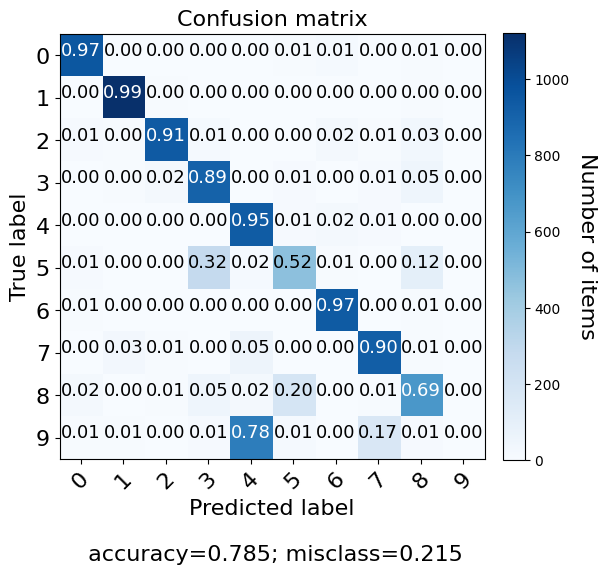

In [19]:
# Plot confusion matrix:
cm = confusion_matrix(real_labels, pred_labels, labels=class_names)
plot_confusion_matrix(cm, target_names=class_names)

### Question - are you satisfied with the confusion matrix?

Is the performance "good enough"? If not, what do you think is the problem, and how could it be solved in a simple manner? And if this is not enough, discuss what else could be done.

### Final questions - could you learn the number of digits?

Imagine that you didn't know the digits (or something else like zebra calls!), and wanted to estimate this. Can you think of how to do that, and would you be sure to get the right result or a reasonable estimate of it?

## Learning Points:
From this exercise, you should:
1. Have understood how Auto-Encoders work, and why they can be used for unsupervised learning.
2. Know that AEs can be used for all types of data that NNs operate on.
3. Know that AEs consist of an encoder and a decoder, and compares input to output as loss function.
4. See the difference between supervised and unsupervised learning in this case (and in general).
5. Understand how AEs can be used for anomaly detection.
6. Be able to apply this or similar algorithms to other datasets, images or not.